# Lets try and work out which is the best base model

In [14]:
# %load_ext autoreload
# %autoreload 2

In [15]:
import strictyaml
import os
import torch
from tqdm.auto import tqdm
from pathlib import Path
from coconut.load_model import resume_model, tie_embeddings, load_new_model
from coconut.utils import Config, clear_memory
from coconut.dataset import (
    CoconutCollator,
    get_cot_latent_dataset,
    get_dataset,
    get_question_only_latent_dataset,
)

In [16]:
from coconut.dataset import (
    CoconutCollator,
    get_cot_latent_dataset,
    get_dataset,
    get_question_only_latent_dataset,
)

In [17]:
import torch
from coconut.eval import evaluate, get_answer_perplexity

from coconut import configs


# torch disable grad
torch.set_grad_enabled(False)

In [ ]:
results = []

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype = torch.bfloat16 if device == 'cuda' else torch.float32

base_models = [
  "yujiepan/qwen3-tiny-random",
  "Qwen/Qwen3-0.6B",
  "Qwen/Qwen3-4B",
  "Qwen/Qwen3-1.7B",
  "suayptalha/Qwen3-0.6B-Math-Expert",
#   "Afaf/qwen3-1.7B-grpo-math",
  "Afaf/Qwen3_1.7B-GRPO-math-reasoning",
    # "HuggingFaceTB/SmolLM-135M-Instruct",
    # "HuggingFaceTB/SmolLM-135M",
]

In [19]:
system_prompts = [
  "",
  "Solve this math question 0-3 steps like `<<5*0+1*2=?>>` OR silently within `<|start-latent|><|end-latent|>`. Shortly, return the final answer like `### 2\n`. Save all comments until after the answer.",
#   "lol",
]

from tqdm.auto import tqdm

In [20]:
# results = []
# for i, model_id in enumerate(tqdm(base_models)):
#     for sys_prompt in system_prompts:
#         print(f"Evaluating {model_id} with system prompt: {sys_prompt}")
#         conf = configs.GSMQwen()
#         conf.load_model_path = configs.GSMQwen()
#         conf.train_path = '../'+conf.train_path
#         conf.val_path = '../'+conf.val_path
#         conf.system_prompt = sys_prompt


#         model, tokenizer = load_new_model(conf, device=device, dtype=dtype)
#         tie_embeddings(model, tokenizer)

#         epoch = 0
#         scheduled_stage = 0
#         no_bot_eot = True

#         # load dataset
#         latent_id = tokenizer.convert_tokens_to_ids("<|latent|>")
#         bot_id = tokenizer.convert_tokens_to_ids("<|start-latent|>")
#         eot_id = tokenizer.convert_tokens_to_ids("<|end-latent|>")
#         collator = CoconutCollator(tokenizer, latent_id=latent_id, label_pad_token_id=-100)
#         max_new_tokens = 256 # need to be longer for base models

#         max_size = 100000000
#         base_dataset_valid = get_dataset(
#             conf.val_path,
#             tokenizer,
#             max_size=max_size // 30 + 3,
#             drop_unused=False,
#             system_prompt=conf.system_prompt,
#             verbose=False,
#         )
#         dataset_gen_val = get_question_only_latent_dataset(
#             scheduled_stage,
#             base_dataset_valid,
#             conf,
#             bot_id,
#             latent_id,
#             eot_id,
#             no_bot_eot=no_bot_eot,
#             # drop_unused=False,
#         )
#         valid_gen_dataloader = torch.utils.data.DataLoader(
#             dataset_gen_val,
#             num_workers=6,
#             pin_memory=True,
#             batch_size=conf.batch_size_training,
#             collate_fn=collator,
#         )

#         r = evaluate(
#             valid_gen_dataloader,
#             model,
#             tokenizer,
#             base_dataset_valid,
#             max_new_tokens=max_new_tokens,
#             name=f"eval_{epoch}_start",
#             dtype=dtype,
#             device=device,
#             quick=False,
#             verbose=1,
#         )
#         r['epoch'] = epoch
#         r['scheduled_stage'] = scheduled_stage
#         r['no_bot_eot'] = no_bot_eot
#         r['max_size'] = max_size
#         r['max_new_tokens'] = max_new_tokens
#         r['model_path'] = str(model_id)
#         r['system_prompt'] = sys_prompt
#         results.append(r)

#         model = None
#         clear_memory()


## Plot

In [21]:
# import pandas as pd
# from matplotlib import pyplot as plt
# df = pd.DataFrame(results).set_index('epoch')
# df[['eval/acc', 'eval/cot_em',]].plot()

# # hmm instead of events, highlight stages?

# stage_epochs = [0]

# a=0
# b = (~df.no_bot_eot).argmax()
# stage_epochs.append(df.index[b])

# ms= df['scheduled_stage'].max()
# for i in range(1, ms+1):
#     dd = df[df.scheduled_stage==i]
#     if len(dd) == 0:
#         continue
#     i_ans = int(dd.index[0])
#     stage_epochs.append(df.loc[i_ans].name)


# # now highlight the stages
# colors = ['red', 'green', 'blue', 'purple', 'orange']
# labels = ['CoT', '<|start-latent|>', '<|latent|>x1', '<|latent|>x2', '<|latent|>x3']
# for i in range(len(stage_epochs)-1):
#     plt.fill_betweenx(
#         *plt.ylim(),
#         stage_epochs[i],
#         stage_epochs[i+1],
#         color=colors[i % len(colors)],
#         label=f'stage {i}',
#         alpha=0.2,
#     )
# plt.legend()

## Try perplexity

In [24]:
base_models = [
  "Afaf/Qwen3_1.7B-GRPO-math-reasoning",
]
for i, model_id in enumerate(tqdm(base_models)):
    for sys_prompt in system_prompts:
        print(f"Evaluating {model_id} with system prompt: {sys_prompt}")
        conf = configs.GSMQwen()
        conf.model_id = model_id
        conf.train_path = '../'+conf.train_path
        conf.val_path = '../'+conf.val_path
        conf.system_prompt = sys_prompt
        conf.batch_size_training = 4 # 12 is ok for the 1b model

        model, tokenizer = load_new_model(conf, device=device, dtype=dtype)
        tie_embeddings(model, tokenizer)

        epoch = 0
        scheduled_stage = 0
        no_bot_eot = True

        # load dataset
        latent_id = tokenizer.convert_tokens_to_ids("<|latent|>")
        bot_id = tokenizer.convert_tokens_to_ids("<|start-latent|>")
        eot_id = tokenizer.convert_tokens_to_ids("<|end-latent|>")
        collator = CoconutCollator(tokenizer, latent_id=latent_id, label_pad_token_id=-100)
        max_new_tokens = 256 # need to be longer for base models

        max_size = 100000000
        base_dataset_valid = get_dataset(
            conf.val_path,
            tokenizer,
            max_size=max_size // 30 + 3,
            drop_unused=False,
            system_prompt=conf.system_prompt,
            verbose=False,
        )
        # base_dataset_train = get_dataset(
        #     conf.train_path, tokenizer, max_size=max_size, verbose=False,
        # )
        # dataset_gen_val = get_question_only_latent_dataset(
        dataset_gen_val = get_cot_latent_dataset(
            scheduled_stage,
            base_dataset_valid,
            conf,
            bot_id,
            latent_id,
            eot_id,
            no_bot_eot=no_bot_eot,
            # drop_unused=False,
        )
        valid_gen_dataloader = torch.utils.data.DataLoader(
            dataset_gen_val,
            num_workers=6,
            pin_memory=True,
            batch_size=conf.batch_size_training,
            collate_fn=collator,
        )

        r = get_answer_perplexity(
            model,
            tokenizer,
            valid_gen_dataloader,
            dtype=dtype,
            device=device,
            verbose=1,
        )
        r['epoch'] = epoch
        r['scheduled_stage'] = scheduled_stage
        r['no_bot_eot'] = no_bot_eot
        r['max_size'] = max_size
        r['max_new_tokens'] = max_new_tokens
        r['model_path'] = str(model_id)
        r['system_prompt'] = sys_prompt
        results.append(r)
        print(r)

        model = None
        clear_memory()


  0%|          | 0/1 [00:00<?, ?it/s]

Evaluating Afaf/Qwen3_1.7B-GRPO-math-reasoning with system prompt: 


tokenizer_config.json:   0%|          | 0.00/10.3k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

tokenize_sample: ../data/gsm_valid.json (num_proc=32):   0%|          | 0/500 [00:00<?, ? examples/s]

process_dataset: cot_latent_0 (num_proc=32):   0%|          | 0/500 [00:00<?, ? examples/s]

PPX:   0%|          | 0/125 [00:00<?, ?it/s]

2025-05-13 18:36:02.066 | INFO     | coconut.eval:get_answer_perplexity:147 - Input: <|im_start|>system
Solve this math question 0-3 steps like `<<5*0+1*2=?>>` OR silently within `<|start-latent|><|end-latent|>`. Shortly, return the final answer like `### 2
`. Save all comments until after the answer.
<|im_end|>
<|im_start|>user
John cuts his grass to 2 inches.  It grows .5 inches per month.  When it gets to 4 inches he cuts it back down to 2 inches.  It cost $100 to get his grass cut.  How much does he pay per year?<|im_end|>
<|im_start|>assistant
<think>

</think>

<<4-2=2>>
<<2/.5=4>>
<<12/4=3>>
<<100*3=300>>
### 300
<|im_end|>
<|im_end|><|im_end|><|im_end|>


2
`. Save all comments until after the answer.

ans: tensor([   17,   198, 28587, 10255,   678,  6042,  3080,  1283,   279,  4226,
          624]) `2
`. Save all comments until after the answer.
` a=43 b=54 l=11 ans_tokens:torch.Size([11]) ans_logits:torch.Size([11, 151672])
{'eval/ppx': np.float64(12078.713892883314), 'eval/ppx_count': 5000, 'eval/ppx_nlls': 46996.0, 'epoch': 0, 'scheduled_stage': 0, 'no_bot_eot': True, 'max_size': 100000000, 'max_new_tokens': 256, 'model_path': 'Afaf/Qwen3_1.7B-GRPO-math-reasoning', 'system_prompt': 'Solve this math question 0-3 steps like `<<5*0+1*2=?>>` OR silently within `<|start-latent|><|end-latent|>`. Shortly, return the final answer like `### 2\n`. Save all comments until after the answer.'}


## Plot

In [27]:
system_prompts

['',
 'Solve this math question 0-3 steps like `<<5*0+1*2=?>>` OR silently within `<|start-latent|><|end-latent|>`. Shortly, return the final answer like `### 2\n`. Save all comments until after the answer.']

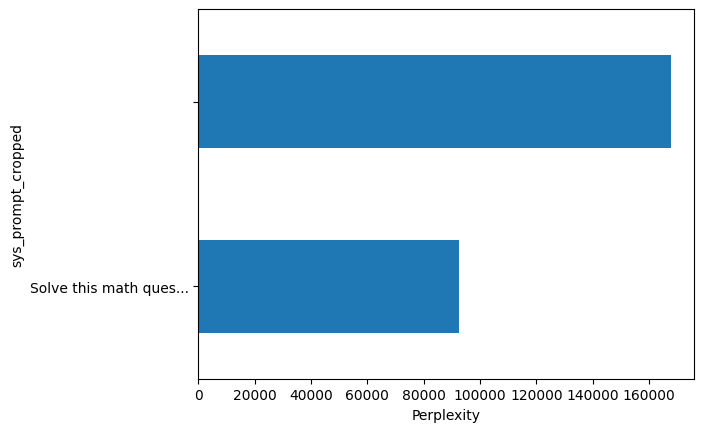

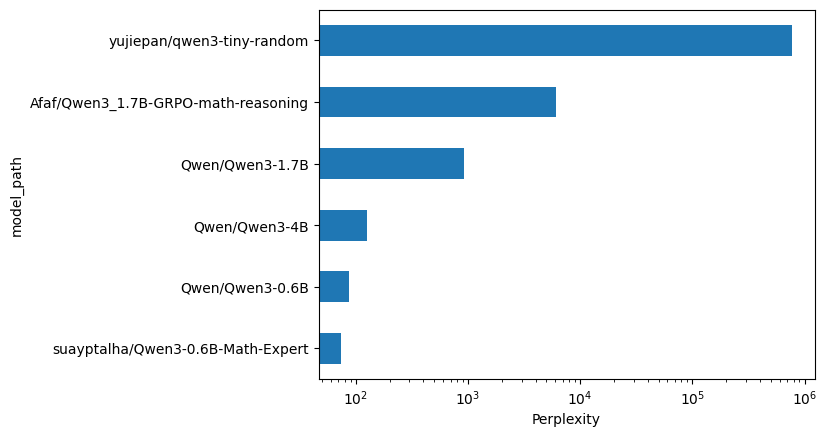

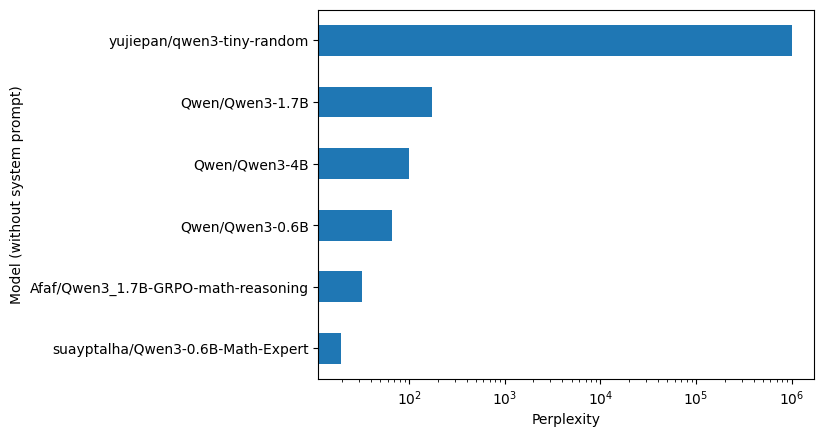

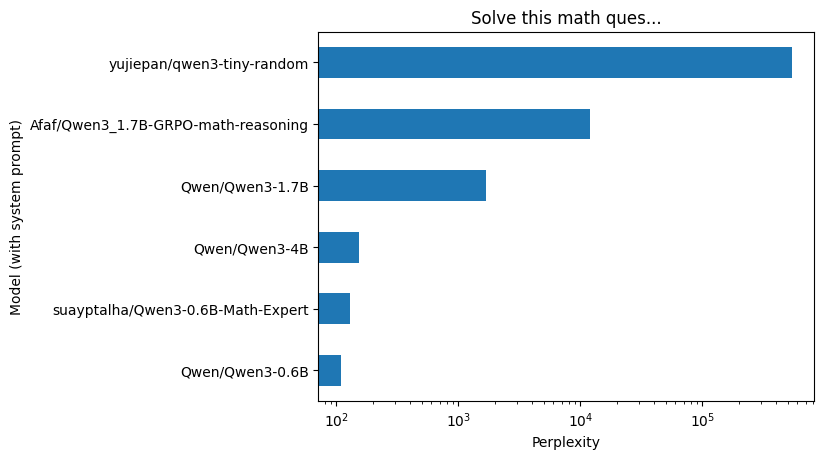

model_path
Qwen/Qwen3-0.6B                           108.809647
suayptalha/Qwen3-0.6B-Math-Expert         128.483437
Qwen/Qwen3-4B                             154.038104
Qwen/Qwen3-1.7B                          1671.037550
Afaf/Qwen3_1.7B-GRPO-math-reasoning     12078.713893
yujiepan/qwen3-tiny-random             540364.937247
Name: eval/ppx, dtype: float64

In [25]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
df = pd.DataFrame(results)
df['sysp_i'] = df['system_prompt'].apply(lambda x: system_prompts.index(x))
df['sys_prompt_cropped'] = df['system_prompt'].apply(lambda x: x[:20] + '...' if len(x) > 20 else x)
df['-log(ppx)'] = -np.log(df['eval/ppx'])


df.groupby('sys_prompt_cropped', as_index=True)['eval/ppx'].mean().sort_values().plot.barh()
plt.xlabel('Perplexity')
plt.show()

d=df.groupby('model_path', as_index=True)['eval/ppx'].mean().sort_values()
d.plot.barh(logx=True)
plt.xlabel('Perplexity')
plt.show()
d


sysp = system_prompts[0]
d=df.query('system_prompt==@sysp').groupby('model_path', as_index=True)['eval/ppx'].mean().sort_values()
d.plot.barh(title=sysp[:20] + '...' if len(sysp) > 20 else sysp, logx=True)
plt.xlabel('Perplexity')
plt.ylabel('Model (without system prompt)')
plt.show()

sysp = system_prompts[1]
d=df.query('system_prompt==@sysp').groupby('model_path', as_index=True)['eval/ppx'].mean().sort_values()
d.plot.barh(title=sysp[:20] + '...' if len(sysp) > 20 else sysp, logx=True)
plt.xlabel('Perplexity')
plt.ylabel('Model (with system prompt)')
plt.show()
d

In [26]:
# Try base models with and without prompt